# **Importing the necessary data analysis libraries**

In [ ]:
# ============================================
# IMPORTING ALL REQUIRED LIBRARIES
# PDM CW2 - Employee Attrition Prediction
# ============================================


# -----------------------------
# Data Handling Libraries
# -----------------------------

import pandas as pd
import numpy as np

# -----------------------------
# Data Visualisation Libraries
# -----------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Data Pre-processing Libraries
# -----------------------------

from sklearn.preprocessing import (LabelEncoder,StandardScaler)

# -----------------------------
# Dataset Splitting Library
# -----------------------------

from sklearn.model_selection import train_test_split

# -----------------------------
# Machine Learning Models
# -----------------------------

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Model Evaluation Metrics
# -----------------------------

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,
    log_loss,roc_auc_score,roc_curve)

# -----------------------------
# Warning Management
# -----------------------------

import warnings
warnings.filterwarnings("ignore")

# **Load HR Operations Dataset**

In [ ]:
# Load HR dataset
hr_df = pd.read_csv("/content/hr_op.csv")

# Display first 5 records
hr_df.head()

,employee_id,job_role,department,tenure_years,monthly_income,overtime_hours,travel_frequency,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition
0,10001,Operations,HR,0.77,4731.09,34.4,Frequent,1,5,4,3,0,0
1,10002,Manager,Technology,8.04,3601.76,9.2,NaN,2,2,23,5,1,0
2,10003,HR,Consulting,7.17,4389.74,24.9,Frequent,3,5,19,3,0,1
3,10004,Operations,Technology,4.56,4575.93,25.9,Occasional,4,5,36,2,0,0
4,10005,Developer,Operations,0.06,2791.37,17.2,NaN,1,2,30,1,0,1


In [ ]:
hr_df.columns

Index(['employee_id', 'job_role', 'department', 'tenure_years',
       'monthly_income', 'overtime_hours', 'travel_frequency',
       'job_satisfaction', 'manager_rating', 'training_hours',
       'work_life_balance_score', 'remote_friendly_role', 'attrition'],
      dtype='object')

# **Load Personal Operations Dataset**

In [ ]:
# Load Personal dataset
personal_df = pd.read_excel("/content/personal_op.xlsx")

# Display first 5 records
personal_df.head()

,employee_id,age,gender,ethnicity,marital_status,disability_status,commute_distance_km,attrition
0,10001,34,Male,Other,Single,NaN,6.0,0
1,10002,33,Female,Other,Widowed,NaN,21.7,0
2,10003,49,Male,White,Widowed,NaN,12.1,1
3,10004,62,Male,Mixed,Married,NaN,18.4,0
4,10005,21,Female,Asian,Married,NaN,5.6,1


In [ ]:
personal_df_clean = personal_df.drop(
    "attrition",
    axis=1
)

# **Check Dataset Dimensions**

In [ ]:
print("HR Dataset Shape:")
print(hr_df.shape)

print("\nPersonal Dataset Shape:")
print(personal_df_clean.shape)

HR Dataset Shape:
(5000, 13)

Personal Dataset Shape:
(5000, 7)


# **Combine Both Datasets Using employee_id Only**

In [ ]:
# Merge datasets using employee_id

employee_df = pd.merge(hr_df,personal_df_clean,on="employee_id",how="inner")
employee_df.head()

,employee_id,job_role,department,tenure_years,monthly_income,overtime_hours,travel_frequency,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition,age,gender,ethnicity,marital_status,disability_status,commute_distance_km
0,10001,Operations,HR,0.77,4731.09,34.4,Frequent,1,5,4,3,0,0,34,Male,Other,Single,NaN,6.0
1,10002,Manager,Technology,8.04,3601.76,9.2,NaN,2,2,23,5,1,0,33,Female,Other,Widowed,NaN,21.7
2,10003,HR,Consulting,7.17,4389.74,24.9,Frequent,3,5,19,3,0,1,49,Male,White,Widowed,NaN,12.1
3,10004,Operations,Technology,4.56,4575.93,25.9,Occasional,4,5,36,2,0,0,62,Male,Mixed,Married,NaN,18.4
4,10005,Developer,Operations,0.06,2791.37,17.2,NaN,1,2,30,1,0,1,21,Female,Asian,Married,NaN,5.6


# **Check Final Combined Dataset**

In [ ]:
employee_df.shape

(5000, 19)

In [ ]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              5000 non-null   int64  
 1   job_role                 5000 non-null   object 
 2   department               5000 non-null   object 
 3   tenure_years             5000 non-null   float64
 4   monthly_income           5000 non-null   float64
 5   overtime_hours           5000 non-null   float64
 6   travel_frequency         3383 non-null   object 
 7   job_satisfaction         5000 non-null   int64  
 8   manager_rating           5000 non-null   int64  
 9   training_hours           5000 non-null   int64  
 10  work_life_balance_score  5000 non-null   int64  
 11  remote_friendly_role     5000 non-null   int64  
 12  attrition                5000 non-null   int64  
 13  age                      5000 non-null   int64  
 14  gender                  

# **Check Duplicate Records After Merge**

In [ ]:
employee_df.duplicated().sum()

np.int64(0)

# **Check Missing Values After Merge**

In [ ]:
employee_df.isnull().sum()

,0
employee_id,0
job_role,0
department,0
tenure_years,0
monthly_income,0
overtime_hours,0
travel_frequency,1617
job_satisfaction,0
manager_rating,0
training_hours,0


In [ ]:
employee_df = employee_df.dropna()

In [ ]:
employee_df.isnull().sum()

,0
employee_id,0
job_role,0
department,0
tenure_years,0
monthly_income,0
overtime_hours,0
travel_frequency,0
job_satisfaction,0
manager_rating,0
training_hours,0


In [ ]:
employee_df.describe()

,employee_id,tenure_years,monthly_income,overtime_hours,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition,age,commute_distance_km
count,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000
mean,12570.086614,2.908819,4097.644094,19.565551,2.986220,3.000000,29.253937,3.023622,0.429134,0.427165,42.141732,14.742913
std,1456.814090,3.139369,1141.746047,13.671780,1.424569,1.386039,17.505268,1.408425,0.495440,0.495154,13.265146,8.666113
min,10013.000000,0.000000,1500.000000,1.300000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,18.000000,0.700000
25%,11197.750000,0.862500,3325.095000,9.250000,2.000000,2.000000,15.000000,2.000000,0.000000,0.000000,32.000000,8.400000
50%,12694.000000,1.915000,4155.235000,16.550000,3.000000,3.000000,30.000000,3.000000,0.000000,0.000000,43.000000,13.150000
75%,13812.500000,3.850000,4756.637500,26.975000,4.000000,4.000000,44.000000,4.000000,1.000000,1.000000,54.000000,19.125000
max,14999.000000,24.080000,7945.310000,88.800000,5.000000,5.000000,59.000000,5.000000,1.000000,1.000000,64.000000,52.700000


# **Target Variable Distribution**

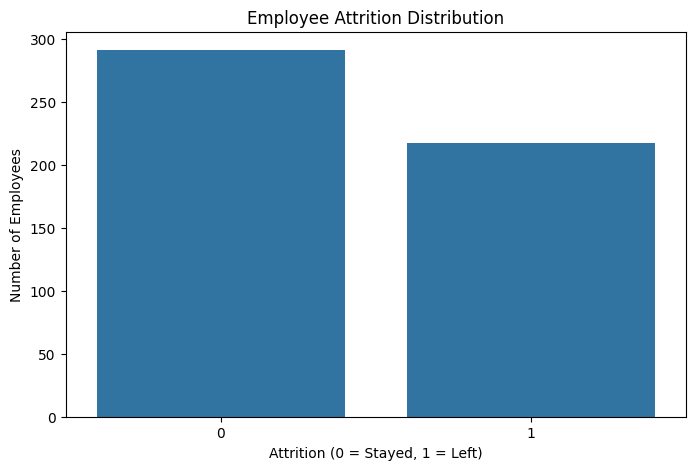

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="attrition",data=employee_df)
plt.title("Employee Attrition Distribution")

plt.xlabel("Attrition (0 = Stayed, 1 = Left)")

plt.ylabel("Number of Employees")

plt.show()

# **Descriptve Analysis**

## **Distribution of Employees by Department**

In [ ]:
# Employee count by department

department_count = (
    employee_df["department"]
    .value_counts()
)

department_count

,count
department,
Operations,108
HR,107
Technology,106
Consulting,104
Finance,83


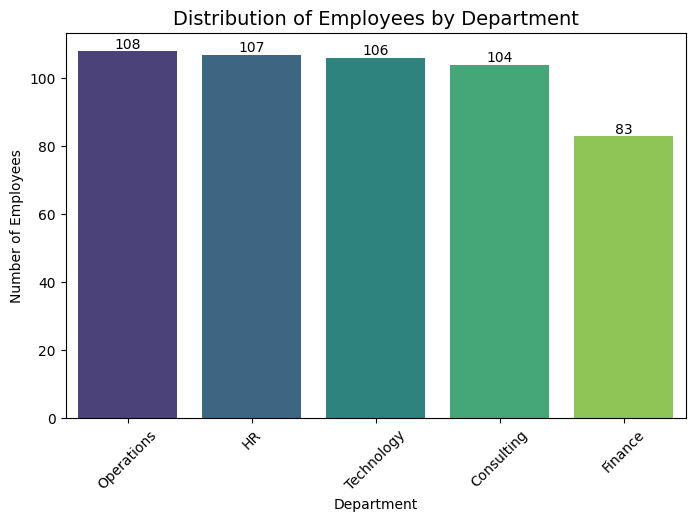

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=department_count.index,
    y=department_count.values,
    palette="viridis"
)


plt.title(
    "Distribution of Employees by Department",
    fontsize=14
)

plt.xlabel("Department")

plt.ylabel("Number of Employees")


# Data labels

for container in ax.containers:
    ax.bar_label(container)


plt.xticks(rotation=45)

plt.show()

# **Distribution of Employees by Job Role**

In [ ]:
jobrole_count = (
    employee_df["job_role"]
    .value_counts()
)


jobrole_count

,count
job_role,
HR,82
Manager,75
Consultant,73
Operations,72
Analyst,72
Finance,67
Developer,67


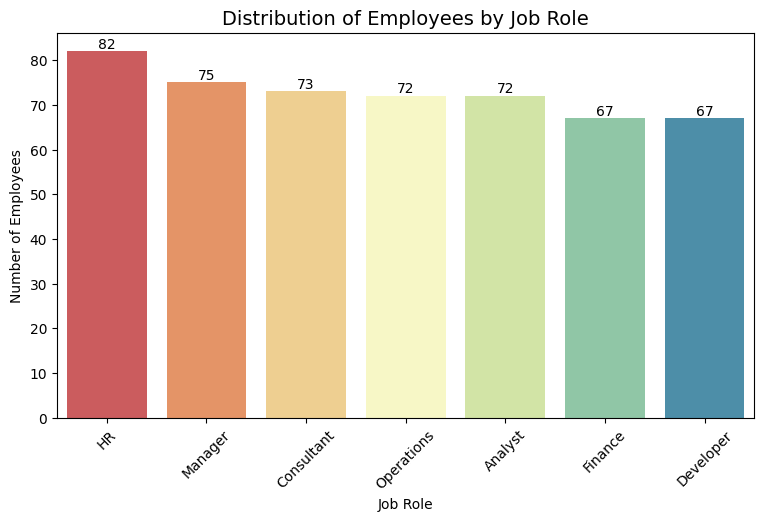

In [ ]:
plt.figure(figsize=(9,5))


ax = sns.barplot(
    x=jobrole_count.index,
    y=jobrole_count.values,
    palette="Spectral"
)


plt.title(
    "Distribution of Employees by Job Role",
    fontsize=14
)


plt.xlabel("Job Role")

plt.ylabel("Number of Employees")


for container in ax.containers:
    ax.bar_label(container)


plt.xticks(rotation=45)

plt.show()

# **Average Tenure Years of Employees**

In [ ]:
average_tenure = employee_df["tenure_years"].mean()


print(
    "Average Tenure:",
    round(average_tenure,2),
    "years"
)

Average Tenure: 2.91 years


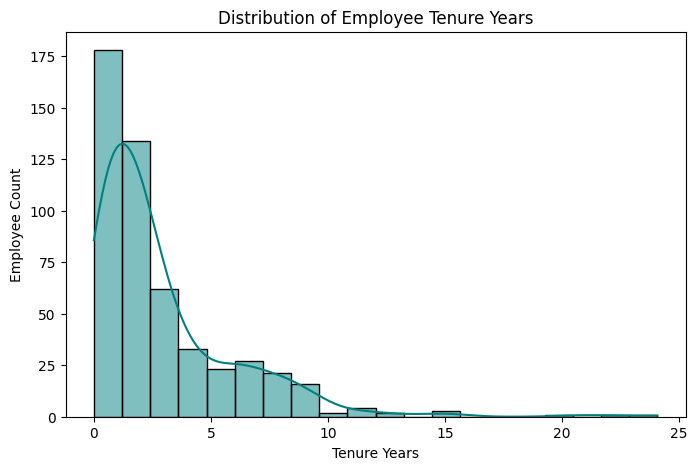

In [ ]:
plt.figure(figsize=(8,5))


sns.histplot(
    employee_df["tenure_years"],
    bins=20,
    kde=True,
    color="teal"
)


plt.title(
    "Distribution of Employee Tenure Years"
)


plt.xlabel(
    "Tenure Years"
)


plt.ylabel(
    "Employee Count"
)


plt.show()

## **Average Monthly Income by Department**

In [ ]:
income_department = (
    employee_df
    .groupby("department")["monthly_income"]
    .mean()
    .sort_values(ascending=False)
)


income_department

,monthly_income
department,
Technology,4176.799057
Finance,4138.847831
HR,4103.739252
Operations,4039.789630
Consulting,4037.891827


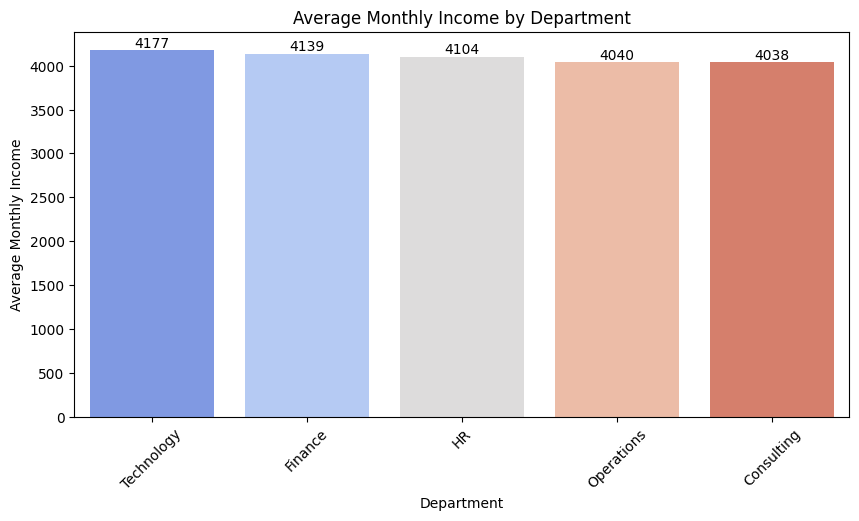

In [ ]:
plt.figure(figsize=(10,5))


ax = sns.barplot(
    x=income_department.index,
    y=income_department.values,
    palette="coolwarm"
)


plt.title(
    "Average Monthly Income by Department"
)


plt.xlabel(
    "Department"
)


plt.ylabel(
    "Average Monthly Income"
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f"
    )


plt.xticks(rotation=45)


plt.show()

# **Average Overtime Hours (Stayed vs Left Employees)**

In [ ]:
overtime_attrition = (
    employee_df
    .groupby("attrition")
    ["overtime_hours"]
    .mean()
)

overtime_attrition

,overtime_hours
attrition,
0,17.122680
1,22.841475


In [ ]:
overtime_attrition.index = [
    "Stayed",
    "Left"
]


overtime_attrition

,overtime_hours
Stayed,17.122680
Left,22.841475


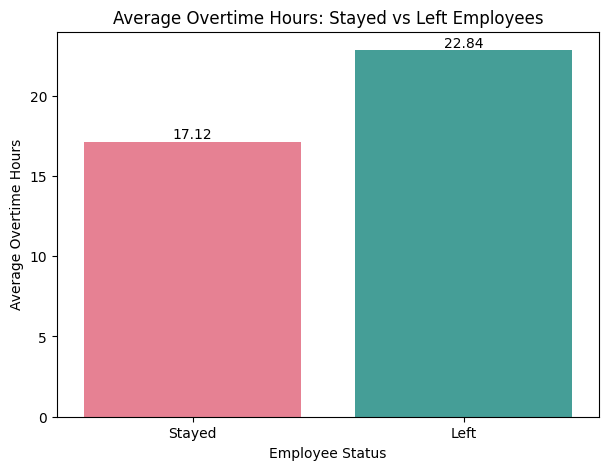

In [ ]:
plt.figure(figsize=(7,5))


ax = sns.barplot(
    x=overtime_attrition.index,
    y=overtime_attrition.values,
    palette="husl"
)


plt.title(
    "Average Overtime Hours: Stayed vs Left Employees"
)


plt.xlabel(
    "Employee Status"
)


plt.ylabel(
    "Average Overtime Hours"
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f"
    )


plt.show()

# **Distribution of Monthly Income**

In [ ]:
employee_df["monthly_income"].describe()

,monthly_income
count,508.000000
mean,4097.644094
std,1141.746047
min,1500.000000
25%,3325.095000
50%,4155.235000
75%,4756.637500
max,7945.310000


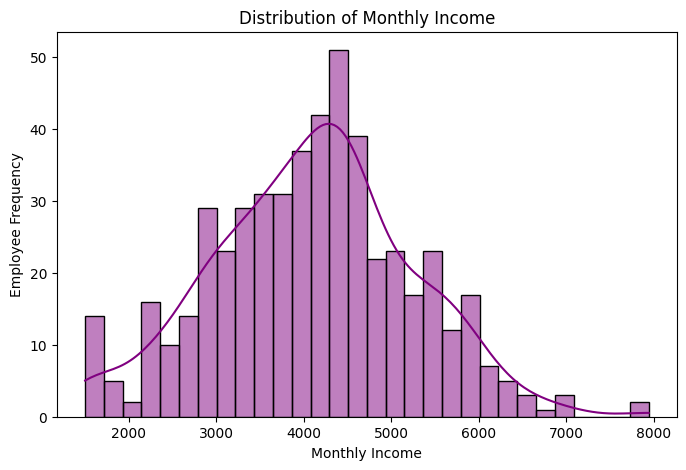

In [ ]:
plt.figure(figsize=(8,5))


sns.histplot(
    employee_df["monthly_income"],
    bins=30,
    kde=True,
    color="purple"
)


plt.title(
    "Distribution of Monthly Income"
)


plt.xlabel(
    "Monthly Income"
)


plt.ylabel(
    "Employee Frequency"
)


plt.show()

# **Distribution of Ethnicity**

In [ ]:
ethnicity_count = (
    employee_df["ethnicity"]
    .value_counts()
)


ethnicity_count

,count
ethnicity,
Black,108
Asian,107
White,106
Other,98
Mixed,89


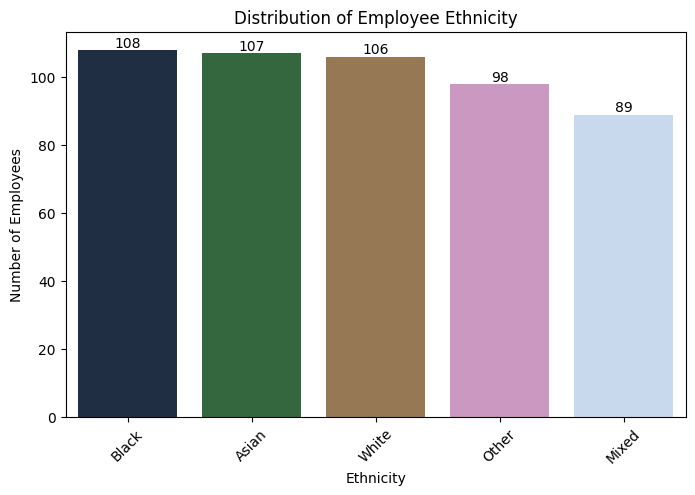

In [ ]:
plt.figure(figsize=(8,5))


ax = sns.barplot(
    x=ethnicity_count.index,
    y=ethnicity_count.values,
    palette="cubehelix"
)


plt.title(
    "Distribution of Employee Ethnicity"
)


plt.xlabel(
    "Ethnicity"
)


plt.ylabel(
    "Number of Employees"
)


for container in ax.containers:
    ax.bar_label(container)


plt.xticks(rotation=45)

plt.show()

# **Average Monthly Income by Gender**

In [ ]:
income_gender = (
    employee_df
    .groupby("gender")
    ["monthly_income"]
    .mean()
)


income_gender

,monthly_income
gender,
Female,4114.321494
Male,4095.730515
Other,4083.912312


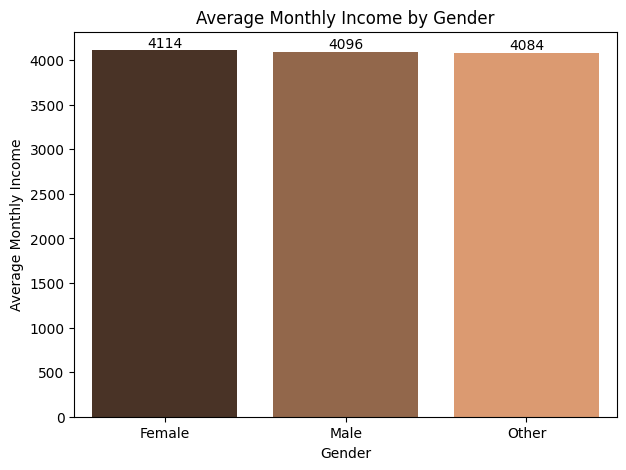

In [ ]:
plt.figure(figsize=(7,5))


ax = sns.barplot(
    x=income_gender.index,
    y=income_gender.values,
    palette="copper"
)


plt.title(
    "Average Monthly Income by Gender"
)


plt.xlabel(
    "Gender"
)


plt.ylabel(
    "Average Monthly Income"
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f"
    )


plt.show()

# **Marital Status Distribution**

In [ ]:
marital_count = (
    employee_df["marital_status"]
    .value_counts()
)


marital_count

,count
marital_status,
Single,132
Widowed,132
Married,131
Divorced,113


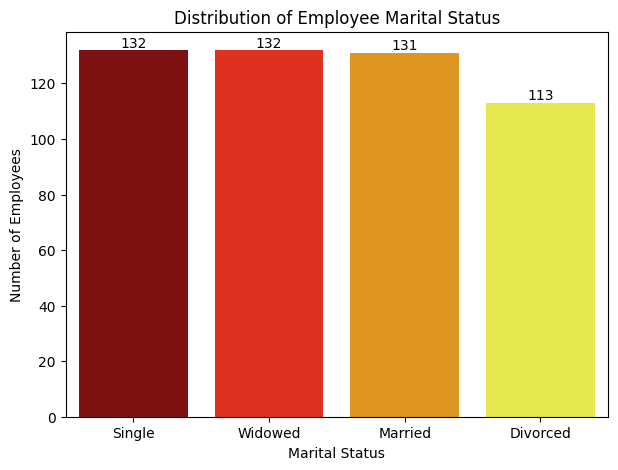

In [ ]:
plt.figure(figsize=(7,5))


ax = sns.barplot(
    x=marital_count.index,
    y=marital_count.values,
    palette="hot"
)


plt.title(
    "Distribution of Employee Marital Status"
)


plt.xlabel(
    "Marital Status"
)


plt.ylabel(
    "Number of Employees"
)


for container in ax.containers:
    ax.bar_label(container)


plt.show()

# **Disability Status Distribution**

In [ ]:
disability_count = (
    employee_df["disability_status"]
    .value_counts()
)


disability_count

,count
disability_status,
Mental,228
Physical,185
Other,93
0,2


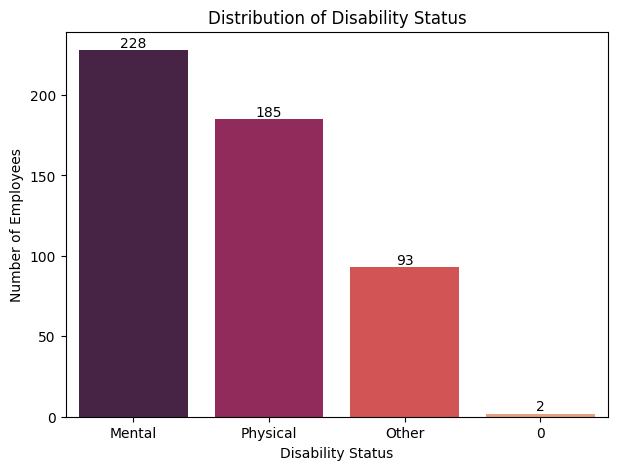

In [ ]:
plt.figure(figsize=(7,5))


ax = sns.barplot(
    x=disability_count.index,
    y=disability_count.values,
    palette="rocket"
)


plt.title(
    "Distribution of Disability Status"
)


plt.xlabel(
    "Disability Status"
)


plt.ylabel(
    "Number of Employees"
)


for container in ax.containers:
    ax.bar_label(container)


plt.show()

# **Relationship Between Overtime Hours, Monthly Income and Work-Life Balance**

In [ ]:
relationship_data = employee_df[
[
    "overtime_hours",
    "monthly_income",
    "work_life_balance_score"
]
]


relationship_data.corr()

,overtime_hours,monthly_income,work_life_balance_score
overtime_hours,1.000000,0.038866,-0.074558
monthly_income,0.038866,1.000000,0.043975
work_life_balance_score,-0.074558,0.043975,1.000000


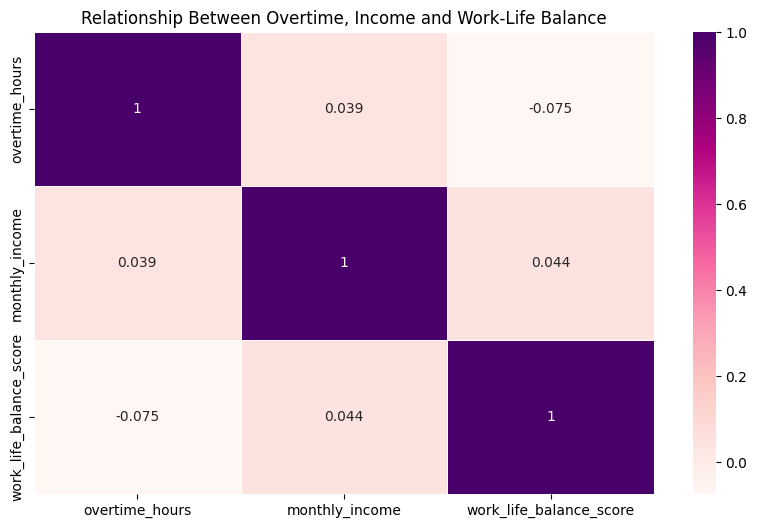

In [ ]:
plt.figure(figsize=(10,6))


sns.heatmap(
    relationship_data.corr(),
    annot=True,
    cmap="RdPu",
    linewidths=0.5
)


plt.title(
    "Relationship Between Overtime, Income and Work-Life Balance"
)


plt.show()

# **Data Preparation**

## **Remove Employee ID Column**

In [ ]:
# Remove ID column
model_df = employee_df.drop("employee_id",axis=1)

## **Separate Features and Target Variable**

In [ ]:
# Independent variables

X = model_df.drop(
    "attrition",
    axis=1
)

# Target variable

y = model_df["attrition"]

# **Identify Categorical Columns**

In [ ]:
categorical_columns = X.select_dtypes(
    include="object"
).columns

# **Encode Categorical Variables**

In [ ]:
encoder = LabelEncoder()


for column in categorical_columns:
    # Convert the column to string type to ensure uniform data type
    X[column] = X[column].astype(str)
    X[column] = encoder.fit_transform(
        X[column]
    )

# **Feature Scaling**

In [ ]:
scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)


X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

================================
# **MODEL 1: NAIVE BAYES**
================================

In [ ]:
nb_model = GaussianNB()

nb_model.fit(X_train,y_train)

GaussianNB()

In [ ]:
nb_prediction = nb_model.predict(X_test)

nb_probability = nb_model.predict_proba(X_test)[:,1]

In [ ]:
nb_accuracy = accuracy_score(
    y_test,
    nb_prediction
)


print(
    "Naive Bayes Accuracy:",
    round(nb_accuracy,4)
)

Naive Bayes Accuracy: 0.6765


In [ ]:
print(
    "Naive Bayes Classification Report"
)


print(
    classification_report(
        y_test,
        nb_prediction
    )
)

Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.66      0.88      0.76        58
           1       0.72      0.41      0.52        44

    accuracy                           0.68       102
   macro avg       0.69      0.64      0.64       102
weighted avg       0.69      0.68      0.65       102



In [ ]:
nb_logloss = log_loss(
    y_test,
    nb_probability
)


print(
    "Naive Bayes Log Loss:",
    round(nb_logloss,4)
)

Naive Bayes Log Loss: 0.5963


In [ ]:
nb_cm = confusion_matrix(
    y_test,
    nb_prediction
)


nb_cm

array([[51,  7],
       [26, 18]])

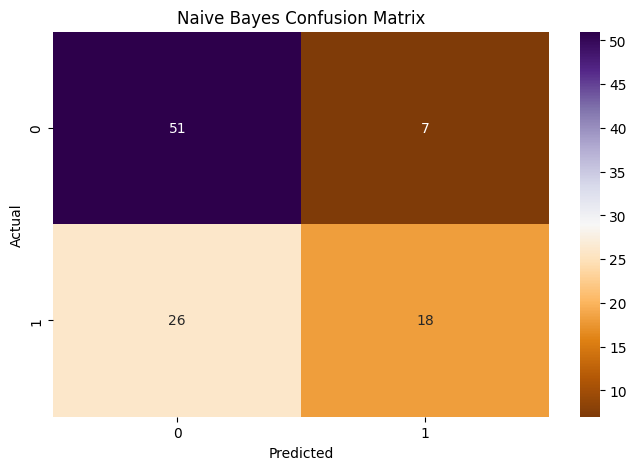

In [ ]:
plt.figure(figsize=(8,5))


sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="PuOr"
)


plt.title(
    "Naive Bayes Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.show()

In [ ]:
nb_auc = roc_auc_score(
    y_test,
    nb_probability
)


print(
    "Naive Bayes ROC-AUC:",
    round(nb_auc,4)
)

Naive Bayes ROC-AUC: 0.7316


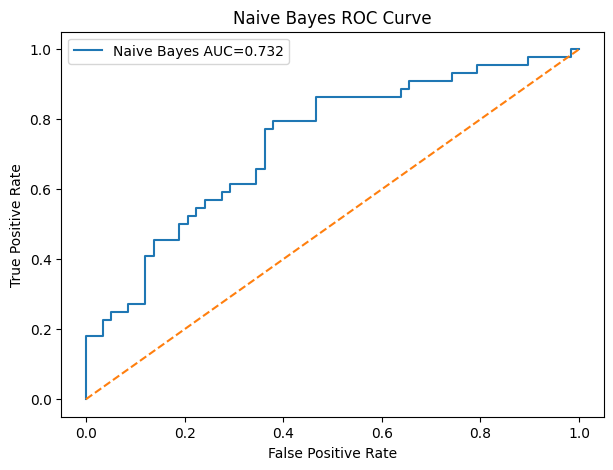

In [ ]:
fpr_nb, tpr_nb, threshold_nb = roc_curve(
    y_test,
    nb_probability
)


plt.figure(figsize=(7,5))


plt.plot(
    fpr_nb,
    tpr_nb,
    label=f"Naive Bayes AUC={nb_auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.title(
    "Naive Bayes ROC Curve"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()


plt.show()

=================================
# **MODEL 2: LOGISTIC REGRESSION**
=================================

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000
)


lr_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
lr_prediction = lr_model.predict(
    X_test
)


lr_probability = lr_model.predict_proba(
    X_test
)[:,1]

In [ ]:
lr_accuracy = accuracy_score(
    y_test,
    lr_prediction
)


print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy,4)
)

Logistic Regression Accuracy: 0.6667


In [ ]:
print(
    "Logistic Regression Classification Report"
)


print(
    classification_report(
        y_test,
        lr_prediction
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.68      0.78      0.73        58
           1       0.64      0.52      0.57        44

    accuracy                           0.67       102
   macro avg       0.66      0.65      0.65       102
weighted avg       0.66      0.67      0.66       102



In [ ]:
lr_logloss = log_loss(
    y_test,
    lr_probability
)


print(
    "Logistic Regression Log Loss:",
    round(lr_logloss,4)
)

Logistic Regression Log Loss: 0.6259


In [ ]:
lr_cm = confusion_matrix(
    y_test,
    lr_prediction
)


lr_cm

array([[45, 13],
       [21, 23]])

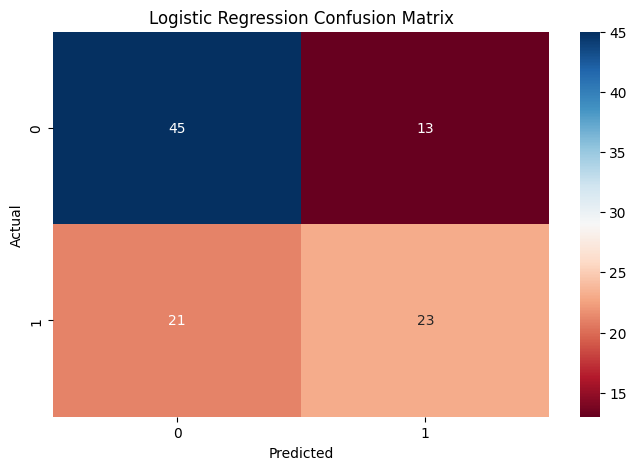

In [ ]:
plt.figure(figsize=(8,5))


sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="RdBu"
)


plt.title(
    "Logistic Regression Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.show()

In [ ]:
lr_auc = roc_auc_score(
    y_test,
    lr_probability
)


print(
    "Logistic Regression ROC-AUC:",
    round(lr_auc,4)
)

Logistic Regression ROC-AUC: 0.6904


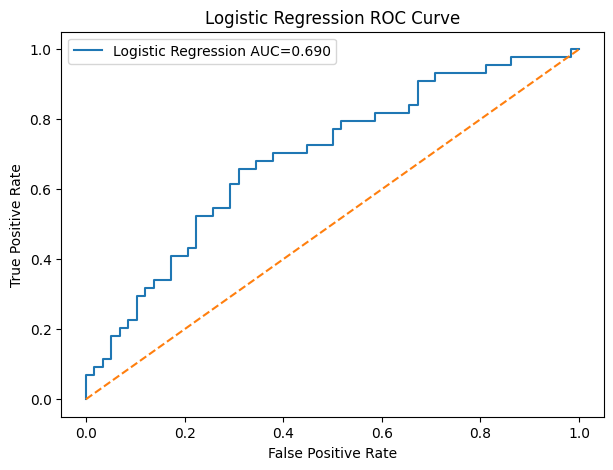

In [ ]:
fpr_lr, tpr_lr, threshold_lr = roc_curve(
    y_test,
    lr_probability
)


plt.figure(figsize=(7,5))


plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression AUC={lr_auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.title(
    "Logistic Regression ROC Curve"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.legend()


plt.show()

# **Model Comparison**

In [ ]:
model_comparison = pd.DataFrame(
{
    "Model":
    [
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy":
    [
        nb_accuracy,
        lr_accuracy
    ],

    "Log Loss":
    [
        nb_logloss,
        lr_logloss
    ],

    "ROC-AUC":
    [
        nb_auc,
        lr_auc
    ]
}
)


model_comparison

,Model,Accuracy,Log Loss,ROC-AUC
0,Naive Bayes,0.676471,0.596301,0.731583
1,Logistic Regression,0.666667,0.625902,0.690439
